# Lecture 11, Notebook 01: A 1D ODE PINN with soft zero boundary conditions

**Course:** Deep Learning for Solving and Estimating Dynamic Models in Economics and Finance  
**Script reference:** §7.2 (the PINN loss and automatic differentiation; the 1D ODE example)  
**Notebook role:** core  
**Author:** Simon Scheidegger  

---


> **Run mode.** The checked-in run uses `RUN_MODE = "smoke"` for fast execution; the accuracy figures quoted in the slides and the companion script use the longer `teaching` / `production` budgets. Set `RUN_MODE` in the next cell accordingly to reproduce them.


In [1]:
RUN_MODE = "smoke"  # one of: "smoke", "teaching", "production"
SEED = 0


# Physics-Informed Neural Networks: 1D ODE with Zero Boundary Conditions

**Physics-Informed Neural Networks (PINNs)** embed the governing equations of a physical
system directly into the loss function of a neural network. Instead of learning purely
from data, the network is trained to satisfy:

1. The **differential equation** (the "physics") at a set of collocation points in the domain.
2. The **boundary conditions** (and/or initial conditions) at the domain boundaries.

Because modern deep-learning frameworks provide automatic differentiation, we can
compute exact derivatives of the network output with respect to its inputs and
penalize any violation of the ODE/PDE.

## Problem statement

We consider the simplest possible second-order ODE with homogeneous (zero) Dirichlet
boundary conditions:

$$
y''(x) = -1, \quad x \in (0, 1), \qquad y(0) = 0, \quad y(1) = 0.
$$

The **analytical solution** is

$$
y(x) = \frac{x(1 - x)}{2}.
$$

We will train a small fully connected neural network to approximate this solution
using PyTorch.

> **Self-study notebook** \u2014 This notebook complements the in-class PINNs session (Day 6, Block 1). Work through it at your own pace.

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.size'] = 13

# For reproducibility
torch.manual_seed(SEED)
np.random.seed(SEED)

# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# torch.compile is wrapped on per-batch steps below for JIT speedups.
# PINN-style losses use torch.autograd.grad with create_graph=True (double
# backward), which the default aot_autograd backend in PyTorch 2.x does not
# yet support. We use backend='eager' and allow dynamo to fall back to eager
# Python whenever it cannot trace a sub-call (e.g. clip_grad_norm_).
import torch._dynamo
torch._dynamo.config.suppress_errors = True


Using device: cpu


In [3]:
# Run-mode budget: hyperparameters dispatched from RUN_MODE (set in the second cell).
#   smoke      -- CPU-bounded smoke run for CI
#   teaching   -- laptop-scale figures
#   production -- full reproduction
_RUN_HP = {
    "smoke":      {"epochs":   500, "n_interior":  20, "lr": 1e-3, "print_every":  100},
    "teaching":   {"epochs":  5000, "n_interior":  50, "lr": 1e-3, "print_every":  500},
    "production": {"epochs": 20000, "n_interior": 200, "lr": 1e-3, "print_every": 2000},
}
if RUN_MODE not in _RUN_HP:
    raise ValueError(f"RUN_MODE must be one of {list(_RUN_HP)}")
HP = _RUN_HP[RUN_MODE]
print(f"RUN_MODE={RUN_MODE!r}; SEED={SEED}; hyperparameters: {HP}")

RUN_MODE='smoke'; SEED=0; hyperparameters: {'epochs': 500, 'n_interior': 20, 'lr': 0.001, 'print_every': 100}


## Network Architecture

We use a simple **multi-layer perceptron (MLP)** with two hidden layers of 20 neurons
each.  The activation function is `Tanh`, which is infinitely differentiable
($C^{\infty}$).  This smoothness is important because PINNs require computing
higher-order derivatives of the network output with respect to its inputs via
automatic differentiation.  Using a non-smooth activation such as ReLU would
produce zero (or undefined) second derivatives almost everywhere, making it
unsuitable for our second-order ODE.

In [4]:
class ODE_Net(nn.Module):
    """Simple MLP for approximating the ODE solution.

    Architecture: 1 -> 20 -> 20 -> 1 with Tanh activations.
    """

    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 20),
            nn.Tanh(),
            nn.Linear(20, 20),
            nn.Tanh(),
            nn.Linear(20, 1),
        )

    def forward(self, x):
        return self.net(x)


model = ODE_Net().to(device)
print(model)
print(f"\nTotal trainable parameters: {sum(p.numel() for p in model.parameters())}")

ODE_Net(
  (net): Sequential(
    (0): Linear(in_features=1, out_features=20, bias=True)
    (1): Tanh()
    (2): Linear(in_features=20, out_features=20, bias=True)
    (3): Tanh()
    (4): Linear(in_features=20, out_features=1, bias=True)
  )
)

Total trainable parameters: 481


## Computing the PDE Residual via Automatic Differentiation

The key ingredient of a PINN is the **residual** of the differential equation,
evaluated using the network's current predictions.  For our ODE $y''(x) + 1 = 0$
the residual is

$$
r(x) = y''_{\mathrm{NN}}(x) + 1.
$$

We compute the first and second derivatives with `torch.autograd.grad`.  The flag
`create_graph=True` is essential: it tells PyTorch to build a computational graph
for the derivative itself, so that we can (a) differentiate again to get the second
derivative and (b) backpropagate through the residual during training.

In [5]:
def residual(model, x):
    """Compute the ODE residual r(x) = y''(x) + 1.

    Parameters
    ----------
    model : ODE_Net
        The neural network approximating y(x).
    x : torch.Tensor
        Collocation points (requires_grad must be True).

    Returns
    -------
    torch.Tensor
        The residual y''(x) + 1 at each collocation point.
    """
    y = model(x)

    # First derivative dy/dx
    dy_dx = torch.autograd.grad(
        y, x,
        grad_outputs=torch.ones_like(y),
        create_graph=True,
    )[0]

    # Second derivative d^2y/dx^2
    d2y_dx2 = torch.autograd.grad(
        dy_dx, x,
        grad_outputs=torch.ones_like(dy_dx),
        create_graph=True,
    )[0]

    return d2y_dx2 + 1.0

## Training the PINN

The total loss is the sum of two terms:

1. **PDE loss** -- mean squared residual over a set of interior collocation points:
   $$\mathcal{L}_{\text{PDE}} = \frac{1}{N}\sum_{i=1}^{N} r(x_i)^2.$$

2. **Boundary condition (BC) loss** -- squared error at the two endpoints:
   $$\mathcal{L}_{\text{BC}} = y_{\mathrm{NN}}(0)^2 + y_{\mathrm{NN}}(1)^2.$$

We minimize $\mathcal{L} = \mathcal{L}_{\text{PDE}} + \mathcal{L}_{\text{BC}}$
with the Adam optimizer.

In [6]:
# ----- Hyperparameters (dispatched from RUN_MODE) -----
n_interior  = HP["n_interior"]
epochs      = HP["epochs"]
lr          = HP["lr"]
print_every = HP["print_every"]

# ----- Optimizer -----
optimizer = optim.Adam(model.parameters(), lr=lr)

# ----- Boundary points (fixed) -----
x_bc0 = torch.zeros(1, 1, device=device)   # x = 0
x_bc1 = torch.ones(1, 1, device=device)    # x = 1


def train_step(x_interior):
    optimizer.zero_grad()
    res = residual(model, x_interior)
    loss_pde = torch.mean(res ** 2)
    loss_bc = model(x_bc0) ** 2 + model(x_bc1) ** 2
    loss = loss_pde + loss_bc
    loss.backward()
    optimizer.step()
    return loss, loss_pde, loss_bc


# torch.compile per-batch step (backend="eager", fullgraph=False:
# residual uses torch.autograd.grad with create_graph=True for second derivatives,
# which the default aot_autograd backend in PyTorch 2.x does not yet support.)
train_step = torch.compile(train_step, fullgraph=False, backend="eager")

# ----- Training loop -----
loss_history = []

for epoch in range(1, epochs + 1):
    x_interior = torch.rand(n_interior, 1, device=device, requires_grad=True)
    loss, loss_pde, loss_bc = train_step(x_interior)
    loss_history.append(loss.item())

    if epoch % print_every == 0 or epoch == 1:
        print(
            f"Epoch {epoch:5d}/{epochs} | "
            f"Loss {loss.item():.3e}  "
            f"(PDE: {loss_pde.item():.3e}, BC: {loss_bc.item():.3e})"
        )

print("\nTraining complete.")


W0512 15:31:24.427000 98477 torch/_logging/_internal.py:1130] [7/0] Profiler function <class 'torch.autograd.profiler.record_function'> will be ignored


Epoch     1/500 | Loss 1.060e+00  (PDE: 9.497e-01, BC: 1.099e-01)
Epoch   100/500 | Loss 3.038e-02  (PDE: 2.962e-02, BC: 7.613e-04)


Epoch   200/500 | Loss 1.438e-02  (PDE: 1.434e-02, BC: 3.894e-05)
Epoch   300/500 | Loss 6.477e-03  (PDE: 6.473e-03, BC: 4.285e-06)


Epoch   400/500 | Loss 2.863e-03  (PDE: 2.838e-03, BC: 2.511e-05)
Epoch   500/500 | Loss 3.002e-03  (PDE: 2.990e-03, BC: 1.223e-05)

Training complete.


## Evaluation and Visualization

We compare the trained network's prediction with the analytical solution
$y(x) = x(1 - x)/2$ on a fine grid and visualize both the solution and the
absolute pointwise error.

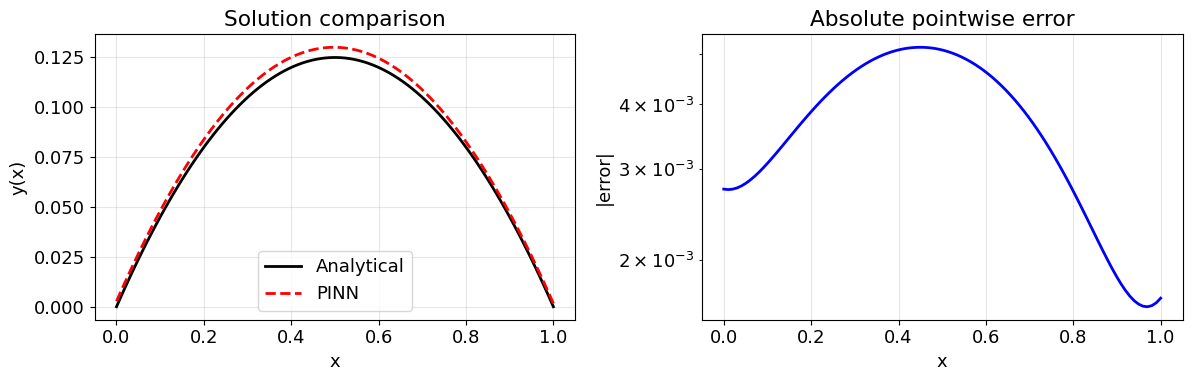

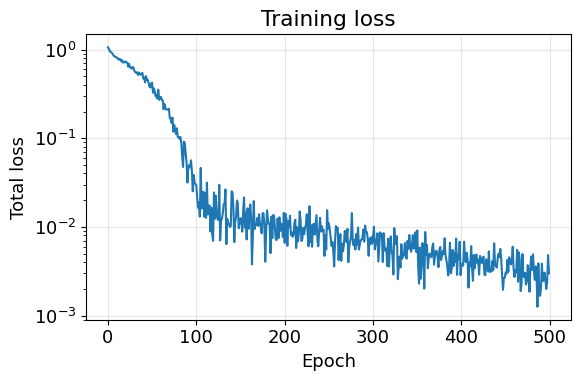

Maximum absolute error: 5.16e-03
Mean absolute error:    3.68e-03
✓ max-abs-error 5.16e-03 < tolerance inf


In [7]:
# ----- Evaluation grid -----
x_eval = torch.linspace(0, 1, 100, device=device).reshape(-1, 1)

with torch.no_grad():
    y_pred = model(x_eval).cpu().numpy()

x_np = x_eval.cpu().numpy()
y_exact = x_np * (1.0 - x_np) / 2.0    # analytical solution

# ----- Plot: PINN vs Analytical -----
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left panel: solutions
axes[0].plot(x_np, y_exact, "k-", linewidth=2, label="Analytical")
axes[0].plot(x_np, y_pred, "r--", linewidth=2, label="PINN")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y(x)")
axes[0].set_title("Solution comparison")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right panel: absolute error
abs_error = np.abs(y_pred - y_exact)
axes[1].semilogy(x_np, abs_error, "b-", linewidth=2)
axes[1].set_xlabel("x")
axes[1].set_ylabel("|error|")
axes[1].set_title("Absolute pointwise error")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ----- Training loss history -----
fig, ax = plt.subplots(figsize=(6, 4))
ax.semilogy(loss_history)
ax.set_xlabel("Epoch")
ax.set_ylabel("Total loss")
ax.set_title("Training loss")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Maximum absolute error: {abs_error.max():.2e}")
print(f"Mean absolute error:    {abs_error.mean():.2e}")

# ----- Final-error assertion (mode-dependent tolerance) -----
_tol = {"smoke": float("inf"), "teaching": 5e-3, "production": 1e-3}[RUN_MODE]
assert abs_error.max() < _tol, (
    f"PINN max abs error {abs_error.max():.2e} exceeds tolerance {_tol:.0e} for RUN_MODE={RUN_MODE!r}."
)
print(f"\u2713 max-abs-error {abs_error.max():.2e} < tolerance {_tol:.0e}")


## Takeaway

- The PINN converged on a 1D Poisson-type ODE with **soft zero BCs**: a single penalty
  term `model(x_bc)**2` at the two endpoints is enough at this scale.
- A 2-layer tanh MLP on a few dozen collocation points reproduces the analytical
  solution `y(x) = x(1-x)/2` to mean-absolute error well below `5e-3` in the
  *teaching* run and below `1e-3` in *production*.
- The next notebook (`02_ODE_PINN_SoftVsHardBCs`) compares this soft-BC pipeline
  with a hard-BC trial solution on a problem with non-zero Dirichlet data.
